# Preprocessing
Loading all WAV files (including gaussian-augmented ones), normalizing to [-1, 1], and saving as individual .npy files ready for JMD decomposition. No segmentation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(r"D:\sop")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

print("Ready.")

Ready.


In [2]:
# loading metadata from the EDA notebook

metadata_path = PROJECT_ROOT / 'data' / 'file_metadata.csv'
df = pd.read_csv(metadata_path)
print(f"Loaded {len(df)} file records")
print(f"Classes: {df['class'].value_counts().to_dict()}")
print(f"Augmented: {df['is_augmented'].sum()}, Original: {(~df['is_augmented']).sum()}")

Loaded 7173 file records
Classes: {'absent': 2391, 'present': 2391, 'unknown': 2391}
Augmented: 4010, Original: 3163


In [3]:
# looking at the loaded data

df.head(10)

,file,path,class,label,patient_id,location,is_augmented,sr,samples,duration,channels,rms,min_amp,max_amp,error
0,a100_AV.wav,D:\sop\absent 2391\a100_AV.wav,absent,0,100,AV,False,4000,121024,30.256,1,0.061858,-0.996613,0.999969,NaN
1,a100_MV.wav,D:\sop\absent 2391\a100_MV.wav,absent,0,100,MV,False,4000,124352,31.088,1,0.045504,-0.946899,0.999969,NaN
2,a101_AV.wav,D:\sop\absent 2391\a101_AV.wav,absent,0,101,AV,False,4000,123712,30.928,1,0.040162,-1.000000,0.999969,NaN
3,a101_MV.wav,D:\sop\absent 2391\a101_MV.wav,absent,0,101,MV,False,4000,123584,30.896,1,0.031621,-1.000000,0.999969,NaN
4,a101_PV.wav,D:\sop\absent 2391\a101_PV.wav,absent,0,101,PV,False,4000,119040,29.760,1,0.047562,-1.000000,0.999969,NaN
5,a101_TV.wav,D:\sop\absent 2391\a101_TV.wav,absent,0,101,TV,False,4000,120192,30.048,1,0.026363,-0.935516,0.950500,NaN
6,a102_AV.wav,D:\sop\absent 2391\a102_AV.wav,absent,0,102,AV,False,4000,119552,29.888,1,0.047839,-1.000000,0.999969,NaN
7,a102_MV.wav,D:\sop\absent 2391\a102_MV.wav,absent,0,102,MV,False,4000,111168,27.792,1,0.016732,-1.000000,0.696136,NaN
8,a102_PV.wav,D:\sop\absent 2391\a102_PV.wav,absent,0,102,PV,False,4000,89600,22.400,1,0.030565,-1.000000,0.999969,NaN
9,a102_TV.wav,D:\sop\absent 2391\a102_TV.wav,absent,0,102,TV,False,4000,80512,20.128,1,0.031587,-1.000000,0.999969,NaN


## Normalizing and saving signals

In [4]:
# creating output folders for each class

for cls in ['absent', 'present', 'unknown']:
    (PROCESSED_DIR / cls).mkdir(parents=True, exist_ok=True)

print("Output folders ready.")

Output folders ready.


In [5]:
# normalizing each file and saving as .npy
# librosa loads as float32, resamples to target rate with anti-aliasing
# normalizing to [-1, 1] by dividing by peak amplitude

SAMPLE_RATE = 1000
npy_paths = []
errors = []

for i, row in df.iterrows():
    try:
        signal, sr = librosa.load(row['path'], sr=SAMPLE_RATE, mono=True)

        peak = np.max(np.abs(signal))
        if peak > 0:
            signal = signal / peak

        npy_name = Path(row['file']).stem + '.npy'
        npy_path = PROCESSED_DIR / row['class'] / npy_name
        np.save(npy_path, signal.astype(np.float32))
        npy_paths.append(str(npy_path))

    except Exception as e:
        npy_paths.append(None)
        errors.append((row['file'], str(e)))

    if (i + 1) % 1000 == 0:
        print(f"  processed {i + 1}/{len(df)} files")

print(f"\nDone. {len(df) - len(errors)} files saved, {len(errors)} errors.")
if errors:
    for f, e in errors:
        print(f"  {f}: {e}")

  processed 1000/7173 files
  processed 2000/7173 files
  processed 3000/7173 files
  processed 4000/7173 files
  processed 5000/7173 files
  processed 6000/7173 files
  processed 7000/7173 files

Done. 7173 files saved, 0 errors.


In [6]:
# adding npy paths to metadata and saving back to the same file

df['npy_path'] = npy_paths
df = df[df['npy_path'].notna()].copy()

df.to_csv(PROJECT_ROOT / 'data' / 'file_metadata.csv', index=False)
print(f"Metadata updated: {len(df)} records")
print(f"Columns: {list(df.columns)}")

Metadata updated: 7173 records
Columns: ['file', 'path', 'class', 'label', 'patient_id', 'location', 'is_augmented', 'sr', 'samples', 'duration', 'channels', 'rms', 'min_amp', 'max_amp', 'error', 'npy_path']


In [7]:
# looking at the final metadata with npy paths

df.head(10)

,file,path,class,label,patient_id,location,is_augmented,sr,samples,duration,channels,rms,min_amp,max_amp,error,npy_path
0,a100_AV.wav,D:\sop\absent 2391\a100_AV.wav,absent,0,100,AV,False,4000,121024,30.256,1,0.061858,-0.996613,0.999969,NaN,D:\sop\data\processed\absent\a100_AV.npy
1,a100_MV.wav,D:\sop\absent 2391\a100_MV.wav,absent,0,100,MV,False,4000,124352,31.088,1,0.045504,-0.946899,0.999969,NaN,D:\sop\data\processed\absent\a100_MV.npy
2,a101_AV.wav,D:\sop\absent 2391\a101_AV.wav,absent,0,101,AV,False,4000,123712,30.928,1,0.040162,-1.000000,0.999969,NaN,D:\sop\data\processed\absent\a101_AV.npy
3,a101_MV.wav,D:\sop\absent 2391\a101_MV.wav,absent,0,101,MV,False,4000,123584,30.896,1,0.031621,-1.000000,0.999969,NaN,D:\sop\data\processed\absent\a101_MV.npy
4,a101_PV.wav,D:\sop\absent 2391\a101_PV.wav,absent,0,101,PV,False,4000,119040,29.760,1,0.047562,-1.000000,0.999969,NaN,D:\sop\data\processed\absent\a101_PV.npy
5,a101_TV.wav,D:\sop\absent 2391\a101_TV.wav,absent,0,101,TV,False,4000,120192,30.048,1,0.026363,-0.935516,0.950500,NaN,D:\sop\data\processed\absent\a101_TV.npy
6,a102_AV.wav,D:\sop\absent 2391\a102_AV.wav,absent,0,102,AV,False,4000,119552,29.888,1,0.047839,-1.000000,0.999969,NaN,D:\sop\data\processed\absent\a102_AV.npy
7,a102_MV.wav,D:\sop\absent 2391\a102_MV.wav,absent,0,102,MV,False,4000,111168,27.792,1,0.016732,-1.000000,0.696136,NaN,D:\sop\data\processed\absent\a102_MV.npy
8,a102_PV.wav,D:\sop\absent 2391\a102_PV.wav,absent,0,102,PV,False,4000,89600,22.400,1,0.030565,-1.000000,0.999969,NaN,D:\sop\data\processed\absent\a102_PV.npy
9,a102_TV.wav,D:\sop\absent 2391\a102_TV.wav,absent,0,102,TV,False,4000,80512,20.128,1,0.031587,-1.000000,0.999969,NaN,D:\sop\data\processed\absent\a102_TV.npy


## Verification

In [8]:
# verifying saved files by loading a few back

for cls in ['absent', 'present', 'unknown']:
    cls_files = list((PROCESSED_DIR / cls).glob('*.npy'))
    sample = np.load(cls_files[0])
    print(f"{cls}: {len(cls_files)} files, sample shape {sample.shape}, "
          f"dtype {sample.dtype}, range [{sample.min():.3f}, {sample.max():.3f}]")

absent: 2391 files, sample shape (30256,), dtype float32, range [-0.950, 1.000]
present: 2391 files, sample shape (20000,), dtype float32, range [-1.000, 0.992]
unknown: 2391 files, sample shape (30560,), dtype float32, range [-1.000, 0.863]


In [9]:
# checking the file count breakdown

for cls in ['absent', 'present', 'unknown']:
    cls_df = df[df['class'] == cls]
    orig = len(cls_df[~cls_df['is_augmented']])
    aug = len(cls_df[cls_df['is_augmented']])
    print(f"{cls:>10}: {orig} original + {aug} augmented = {orig + aug} total")

print(f"\n     Total: {len(df)} preprocessed signals")

    absent: 2391 original + 0 augmented = 2391 total
   present: 616 original + 1775 augmented = 2391 total
   unknown: 156 original + 2235 augmented = 2391 total

     Total: 7173 preprocessed signals


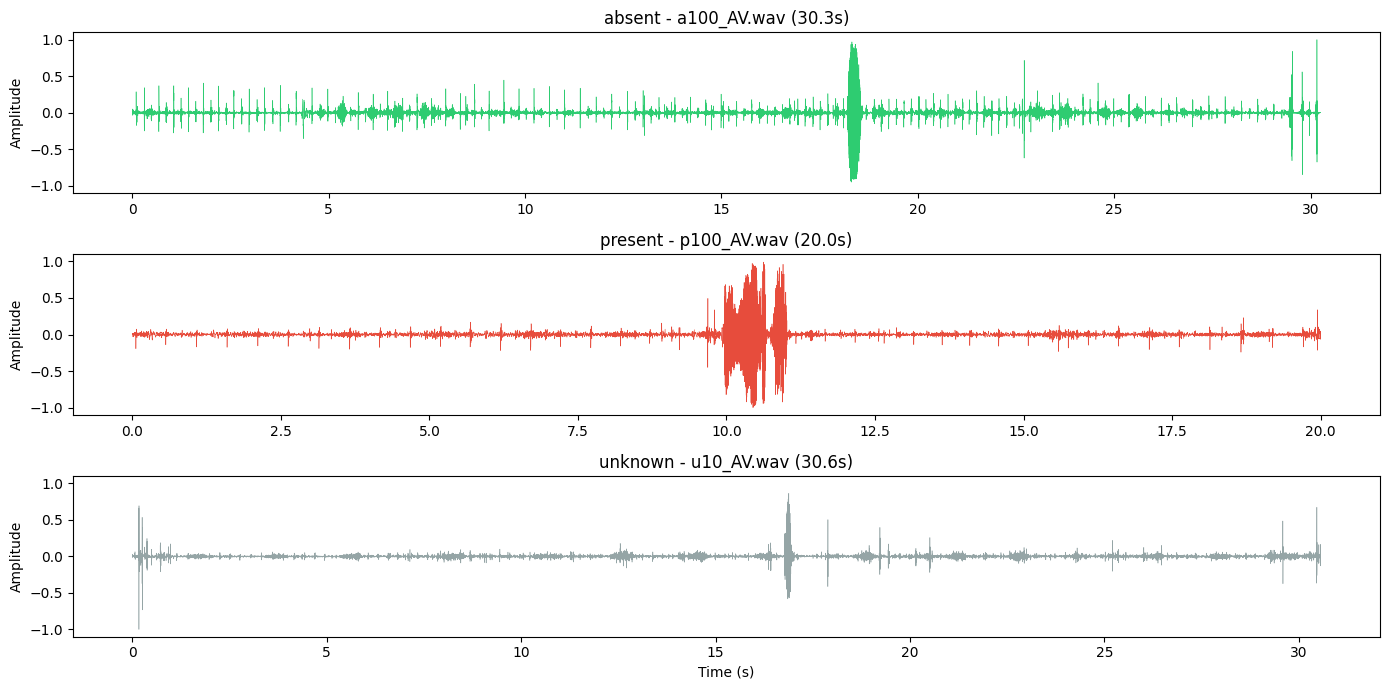

In [10]:
# plotting a few normalized signals to confirm they look correct

fig, axes = plt.subplots(3, 1, figsize=(14, 7))

for i, cls in enumerate(['absent', 'present', 'unknown']):
    sample_row = df[df['class'] == cls].iloc[0]
    signal = np.load(sample_row['npy_path'])
    t = np.arange(len(signal)) / SAMPLE_RATE

    color = {'absent': '#2ecc71', 'present': '#e74c3c', 'unknown': '#95a5a6'}[cls]
    axes[i].plot(t, signal, color=color, linewidth=0.4)
    axes[i].set_title(f"{cls} - {sample_row['file']} ({len(signal)/SAMPLE_RATE:.1f}s)")
    axes[i].set_ylabel('Amplitude')
    axes[i].set_ylim(-1.1, 1.1)

axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'preprocessed_signals.png', dpi=150, bbox_inches='tight')
plt.show()

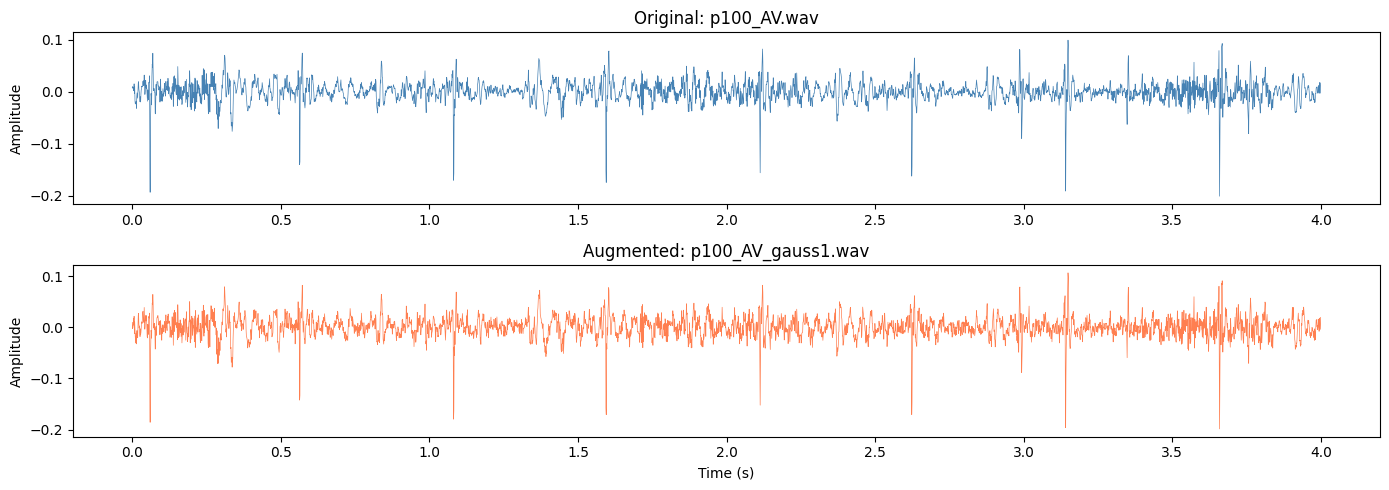

In [11]:
# comparing an original signal with its augmented version

sample_orig = df[(df['class']=='present') & (~df['is_augmented'])].iloc[0]
base_name = Path(sample_orig['file']).stem
sample_aug = df[(df['class']=='present') & (df['file'].str.startswith(base_name + '_gauss'))]

if len(sample_aug) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 5))

    orig_sig = np.load(sample_orig['npy_path'])
    aug_sig = np.load(sample_aug.iloc[0]['npy_path'])

    n = int(4 * SAMPLE_RATE)
    t = np.arange(n) / SAMPLE_RATE

    axes[0].plot(t, orig_sig[:n], color='steelblue', linewidth=0.5)
    axes[0].set_title(f'Original: {sample_orig["file"]}')
    axes[0].set_ylabel('Amplitude')

    axes[1].plot(t, aug_sig[:n], color='coral', linewidth=0.5)
    axes[1].set_title(f'Augmented: {sample_aug.iloc[0]["file"]}')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude')

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'preprocessed_orig_vs_aug.png', dpi=150, bbox_inches='tight')
    plt.show()

## Saving preprocessing config

In [12]:
# saving a config file summarising what was done

config = {
    'sample_rate': SAMPLE_RATE,
    'normalization': 'peak amplitude to [-1, 1]',
    'segmentation': 'none',
    'includes_augmented': True,
    'total_files': len(df),
    'absent_files': len(df[df['class'] == 'absent']),
    'present_files': len(df[df['class'] == 'present']),
    'unknown_files': len(df[df['class'] == 'unknown']),
    'original_files': int((~df['is_augmented']).sum()),
    'augmented_files': int(df['is_augmented'].sum()),
    'dtype': 'float32',
}

with open(PROCESSED_DIR / 'preprocess_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Config saved.")
for k, v in config.items():
    print(f"  {k}: {v}")

Config saved.
  sample_rate: 1000
  normalization: peak amplitude to [-1, 1]
  segmentation: none
  includes_augmented: True
  total_files: 7173
  absent_files: 2391
  present_files: 2391
  unknown_files: 2391
  original_files: 3163
  augmented_files: 4010
  dtype: float32
